=== Stealth Hedef Testi ===
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 1200 m
  Pr: 1.75e-13 W
  SNR: 12.40 dB
  Tespit: EVET (Threshold: 12 dB)

=== Normal Hedef Testi ===
Monostatik Radar:
  RCS: 5.0000 m²
  Menzil: 1200 m
  Pr: 1.09e-11 W
  SNR: 30.36 dB
  Tespit: EVET (Threshold: 12 dB)
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 100.0 m
  Pr: 3.62e-09 W
  SNR: 55.57 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 149.49494949494948 m
  Pr: 7.25e-10 W
  SNR: 48.58 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 198.989898989899 m
  Pr: 2.31e-10 W
  SNR: 43.61 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 248.4848484848485 m
  Pr: 9.50e-11 W
  SNR: 39.75 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 297.979797979798 m
  Pr: 4.60e-11 W
  SNR: 36.60 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 347.47474747474746 m
  Pr: 2.49e-11 W
  SNR: 33.93 dB
Monostatik Radar:
  RCS: 0.0800 m²
  Menzil: 396.969696969697 m
  Pr: 1.46e-11 W
  SNR: 31.62 dB
Monostatik Radar:
  RCS: 0.0800 m

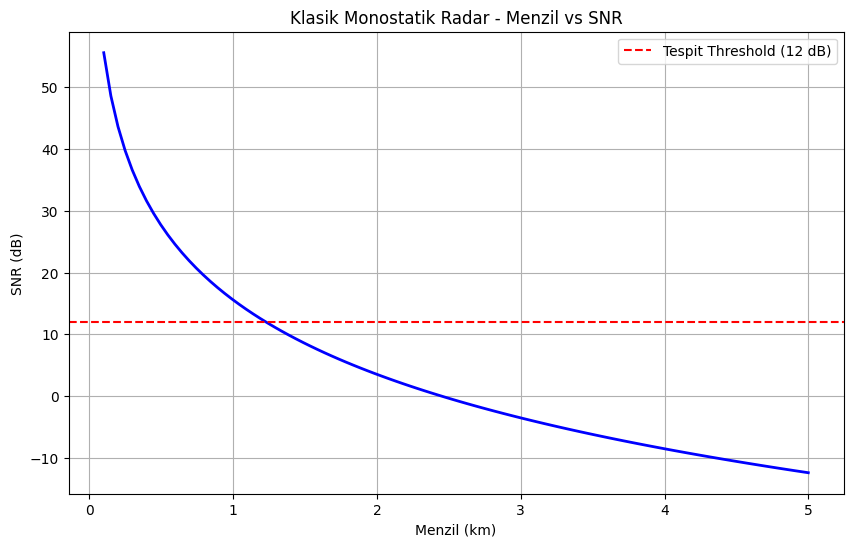

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

class MonostaticRadar:
    """
    Klasik Monostatik Radar (Matlab kodundan çevrilmiş)
    """
    def __init__(self):
        self.c = constants.c
        self.freq = 10e9          # 10 GHz
        self.lambda_ = self.c / self.freq
        self.k = 2 * np.pi / self.lambda_
        self.pt = 1000            # Transmit power (W)
        self.g = 100              # Antenna gain
        self.noise_fig = 4        # Noise figure (dB)
    
    def radar_equation(self, rcs, range_m):
        """Radar Denklemi"""
        pr = (self.pt * self.g**2 * self.lambda_**2 * rcs) / \
             ((4 * np.pi)**3 * range_m**4)
        
        # Gürültü
        kT = constants.k * 290
        bandwidth = 1e6
        noise_power = kT * bandwidth * 10**(self.noise_fig/10)
        
        snr = 10 * np.log10(pr / noise_power)
        
        print(f"Monostatik Radar:")
        print(f"  RCS: {rcs:.4f} m²")
        print(f"  Menzil: {range_m} m")
        print(f"  Pr: {pr:.2e} W")
        print(f"  SNR: {snr:.2f} dB")
        return snr, pr
    
    def detect(self, rcs=0.08, range_m=1200, snr_threshold=12):
        """Tespit Kararı"""
        snr, pr = self.radar_equation(rcs, range_m)
        detected = snr > snr_threshold
        print(f"  Tespit: {'EVET' if detected else 'HAYIR'} (Threshold: {snr_threshold} dB)")
        return detected, snr
    
    def plot_rcs_vs_range(self, rcs=0.08, ranges=np.linspace(100, 5000, 100)):
        """RCS vs Menzil Grafiği"""
        snrs = []
        for r in ranges:
            snr, _ = self.radar_equation(rcs, r)
            snrs.append(snr)
        
        plt.figure(figsize=(10, 6))
        plt.plot(ranges/1000, snrs, 'b-', linewidth=2)
        plt.axhline(y=12, color='r', linestyle='--', label='Tespit Threshold (12 dB)')
        plt.title('Klasik Monostatik Radar - Menzil vs SNR')
        plt.xlabel('Menzil (km)')
        plt.ylabel('SNR (dB)')
        plt.grid(True)
        plt.legend()
        plt.show()

# ====================== TEST ======================
radar = MonostaticRadar()

print("=== Stealth Hedef Testi ===")
radar.detect(rcs=0.08, range_m=1200)

print("\n=== Normal Hedef Testi ===")
radar.detect(rcs=5, range_m=1200)

# Grafik
radar.plot_rcs_vs_range(rcs=0.08)

# 